# Schritt 1: Textklassifikation mit Large Language Models und Hugging Face

**Maschinelles Lernen mit Python – Erweiterung: Large Language Models**

---

## Einordnung in den Kurs

| Konzept | Im Kurs bisher | In diesem Notebook |
|---------|---------------|-------------------|
| Transfer Learning | Kap. 10: VGG19, vortrainierte Bildgewichte | BERT: vortrainiertes Sprachmodell |
| Pipeline | Kap. 2: StandardScaler + Modell | `pipeline('text-classification')` |
| Klassifikation | Kap. 5: Logistische Regression | Transformer-Klassifikator |
| Parameteranzahl | Kap. 10: CNN ~225.000 Parameter | BERT: ~110 Mio. Parameter |

**Zeitaufwand**: ca. 40–50 Minuten
**Voraussetzung**: Kap. 5 (Klassifikation) und Kap. 10 (Transfer Learning)

---

## Leitfragen

- Was ist ein Transformer – und warum ist er besser als frühere Sprachmodelle?
- Warum heißen diese Modelle „Large Language Models"?
- Was bedeutet Zero-Shot-Klassifikation – und warum braucht man keine Trainingsdaten?
- Wann versagt das Modell – und was sind seine Grenzen?
- Was ist der Zusammenhang zwischen `include_top=False` bei VGG19 und Fine-Tuning bei BERT?

# Schritt 2: Installation
## Einmalig ausführen (dauert ca. 1–2 Minuten in Colab)

In [1]:
!pip install transformers -q
print('Installation abgeschlossen.')

Installation abgeschlossen.


# Schritt 3: Bibliotheken importieren

In [2]:
import time
import warnings
import numpy as np
import matplotlib.pyplot as plt
from transformers import pipeline, AutoTokenizer

warnings.filterwarnings('ignore')
print('Bibliotheken geladen.')

Bibliotheken geladen.


# Schritt 4: Was ist ein Transformer? – Konzeptuelle Grundlage

## Von RNN zu Transformer

Frühere Sprachmodelle (RNNs, LSTMs) haben Text **sequenziell** verarbeitet –
Wort für Wort, von links nach rechts. Das hatte zwei Probleme:

1. **Langsam** – keine Parallelisierung möglich
2. **Vergessen** – weit entfernte Wörter wurden schlecht berücksichtigt

Der **Transformer** (Vaswani et al., 2017) löst das durch **Self-Attention**:
Jedes Wort „schaut" auf alle anderen Wörter gleichzeitig und bewertet, welche
für sein Verständnis relevant sind.

Beispiel:
> *„The animal didn't cross the street because **it** was too tired."*

Ein Transformer versteht: „it" bezieht sich auf „animal", nicht auf „street" –
weil er den gesamten Satz parallel verarbeitet.

## BERT – das Basis-Sprachmodell

**BERT** (Bidirectional Encoder Representations from Transformers, Google 2018):

- Trainiert auf **Wikipedia + BookCorpus** (3,3 Mrd. Wörter)
- Lernt allgemeines Sprachverständnis (Grammatik, Bedeutung, Kontext)
- Kann dann für spezifische Aufgaben **fine-getuned** werden

**Verbindung zu Kap. 10:**
Genau wie VGG19 mit `include_top=False` den Convolutional-Teil beibehält
und nur den Klassifikationskopf ersetzt, behält BERT seinen Sprachkern
und bekommt einen neuen Aufgaben-Kopf (Sentiment, NER, QA, ...).

# Schritt 5: Warum heißen sie „Large"? – Parametervergleich

## Modellgrößen im Kontext

Bevor wir die Modelle laden, schauen wir uns an, **wie groß** sie tatsächlich sind –
im Vergleich zu den Modellen, die wir bisher gebaut haben.

In [3]:
print("=" * 58)
print("Parametervergleich: Unsere Modelle vs. LLMs")
print("=" * 58)

modelle = [
    ("MLP Variante A (K10_02)",          101_770),
    ("MLP Variante B (K10_03)",          266_610),
    ("CNN Fashion-MNIST (K10_04)",        225_034),
    ("VGG19 Kopf trainierbar (K10_06)",   65_793),
    ("VGG19 gesamt (K10_06)",         14_849_345),
    ("DistilBERT (hier verwendet)",   66_000_000),
    ("BERT-base",                    110_000_000),
    ("BART-large (Zero-Shot)",        400_000_000),
    ("GPT-3",                     175_000_000_000),
]

max_params = max(p for _, p in modelle)

print(f"\n{'Modell':<38} {'Parameter':>15}  Balken")
print("─" * 75)
for name, params in modelle:
    bar_len = max(1, int(params / max_params * 30))
    bar = '█' * bar_len
    marker = " ← wir sind hier" if "DistilBERT" in name else ""
    print(f"{name:<38} {params:>15,}  {bar}{marker}")

print()
print(f"Unser CNN hat ~225 Tsd. Parameter.")
print(f"DistilBERT hat ~66 Mio. Parameter → {66_000_000 // 225_034}× mehr als unser CNN.")
print(f"GPT-3 hat 175 Mrd. Parameter       → {175_000_000_000 // 225_034:,}× mehr als unser CNN.")
print()
print("Das ist der Grund für 'Large' in Large Language Models.")

Parametervergleich: Unsere Modelle vs. LLMs

Modell                                       Parameter  Balken
───────────────────────────────────────────────────────────────────────────
MLP Variante A (K10_02)                        101,770  █
MLP Variante B (K10_03)                        266,610  █
CNN Fashion-MNIST (K10_04)                     225,034  █
VGG19 Kopf trainierbar (K10_06)                 65,793  █
VGG19 gesamt (K10_06)                       14,849,345  █
DistilBERT (hier verwendet)                 66,000,000  █ ← wir sind hier
BERT-base                                  110,000,000  █
BART-large (Zero-Shot)                     400,000,000  █
GPT-3                                  175,000,000,000  ██████████████████████████████

Unser CNN hat ~225 Tsd. Parameter.
DistilBERT hat ~66 Mio. Parameter → 293× mehr als unser CNN.
GPT-3 hat 175 Mrd. Parameter       → 777,660× mehr als unser CNN.

Das ist der Grund für 'Large' in Large Language Models.


# Schritt 6: Tokenisierung – wie Text zu Zahlen wird

## Was passiert, bevor das Modell arbeitet?

Ein neuronales Netz kann keinen Text direkt verarbeiten – nur Zahlen.
Der **Tokenizer** übernimmt die Übersetzung: Text → Token-IDs.

Wichtig: BERT verwendet **WordPiece-Tokenisierung** – unbekannte Wörter
werden in Teilwörter zerlegt, damit auch seltene Wörter verarbeitbar sind.

Wir schauen uns an, wie das konkret aussieht:

In [4]:
tokenizer = AutoTokenizer.from_pretrained(
    'distilbert-base-uncased-finetuned-sst-2-english'
)

beispiele = [
    "This movie is great!",
    "Transformers are amazing models.",
    "supercalifragilisticexpialidocious"   # Seltenes Wort → wird zerlegt
]

print("Tokenisierung: Text → Token-IDs → zurück zu Tokens")
print("=" * 60)

for text in beispiele:
    tokens = tokenizer(text)
    token_strings = tokenizer.convert_ids_to_tokens(tokens['input_ids'])
    print(f"\nText:    {text}")
    print(f"Tokens:  {token_strings}")
    print(f"IDs:     {tokens['input_ids']}")
    print(f"Länge:   {len(tokens['input_ids'])} Token")

print()
print("Beobachtung:")
print("  [CLS] = Beginn-Token (Classification Token)")
print("  [SEP] = Ende-Token (Separator)")
print("  '##'  = Teilwort (WordPiece-Zerlegung)")
print()
print("Erst nach der Tokenisierung verarbeitet das Modell den Text.")

config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Tokenisierung: Text → Token-IDs → zurück zu Tokens

Text:    This movie is great!
Tokens:  ['[CLS]', 'this', 'movie', 'is', 'great', '!', '[SEP]']
IDs:     [101, 2023, 3185, 2003, 2307, 999, 102]
Länge:   7 Token

Text:    Transformers are amazing models.
Tokens:  ['[CLS]', 'transformers', 'are', 'amazing', 'models', '.', '[SEP]']
IDs:     [101, 19081, 2024, 6429, 4275, 1012, 102]
Länge:   7 Token

Text:    supercalifragilisticexpialidocious
Tokens:  ['[CLS]', 'super', '##cal', '##if', '##rag', '##ilis', '##tic', '##ex', '##pia', '##lid', '##oc', '##ious', '[SEP]']
IDs:     [101, 3565, 9289, 10128, 29181, 24411, 4588, 10288, 19312, 21273, 10085, 6313, 102]
Länge:   13 Token

Beobachtung:
  [CLS] = Beginn-Token (Classification Token)
  [SEP] = Ende-Token (Separator)
  '##'  = Teilwort (WordPiece-Zerlegung)

Erst nach der Tokenisierung verarbeitet das Modell den Text.


# ══════════════════════════════════════════════════════
# TEIL 1: Sentiment-Analyse
# ══════════════════════════════════════════════════════

# Schritt 7: Sentiment-Modell laden
## DistilBERT – schnelles, kompaktes Modell

`distilbert-base-uncased-finetuned-sst-2-english` ist:

- **DistilBERT**: eine komprimierte BERT-Variante (~40% kleiner, ~60% schneller)
- **finetuned-sst-2**: auf dem Stanford Sentiment Treebank Fine-Tuned
- Nur 2 Klassen: POSITIVE / NEGATIVE

Beim ersten Aufruf wird das Modell heruntergeladen (~250 MB).

In [5]:
print("Lade DistilBERT-Sentiment-Modell (~250 MB)...")
start = time.time()

sentiment = pipeline(
    'text-classification',
    model='distilbert-base-uncased-finetuned-sst-2-english'
)

elapsed = time.time() - start
print(f"Modell geladen in {elapsed:.1f} Sekunden.")

Lade DistilBERT-Sentiment-Modell (~250 MB)...


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Modell geladen in 3.0 Sekunden.


# Schritt 8: Erste Vorhersage
## Einzelnen Text klassifizieren

In [6]:
text = "This lecture was absolutely fantastic. I learned so much!"

start = time.time()
ergebnis = sentiment(text)
elapsed = time.time() - start

print(f"Text:       {text}")
print(f"Vorhersage: {ergebnis[0]['label']}")
print(f"Konfidenz:  {ergebnis[0]['score']:.1%}")
print(f"Inferenzzeit: {elapsed*1000:.0f} ms")
print()
print("Zum Vergleich: 66 Mio. Parameter – Vorhersage in Millisekunden.")

Text:       This lecture was absolutely fantastic. I learned so much!
Vorhersage: POSITIVE
Konfidenz:  100.0%
Inferenzzeit: 212 ms

Zum Vergleich: 66 Mio. Parameter – Vorhersage in Millisekunden.


# Schritt 9: Mehrere Texte klassifizieren
## Batch-Inferenz

Wir klassifizieren mehrere Texte auf einmal – inklusive eines mehrdeutigen Texts.

In [7]:
texte = [
    "The product broke after two days. Completely useless!",
    "Great customer service, very helpful staff.",
    "It was okay, nothing special.",
    "I hate Mondays.",
    "The weather is so nice today!"
]

start = time.time()
ergebnisse = sentiment(texte)
elapsed = time.time() - start

header = f"{'Text':<45} {'Label':<10} {'Konfidenz':>10}"
print(header)
print('-' * 68)
for text, res in zip(texte, ergebnisse):
    label = res['label']
    score = res['score']
    emoji = 'POS' if label == 'POSITIVE' else 'NEG'
    print(f"{text[:42]:<45} {emoji+' '+label:<10} {score:>9.1%}")

print(f"\nInferenzzeit (5 Texte): {elapsed*1000:.0f} ms")

Text                                          Label       Konfidenz
--------------------------------------------------------------------
The product broke after two days. Complete    NEG NEGATIVE    100.0%
Great customer service, very helpful staff    POS POSITIVE    100.0%
It was okay, nothing special.                 NEG NEGATIVE     98.2%
I hate Mondays.                               NEG NEGATIVE     99.7%
The weather is so nice today!                 POS POSITIVE    100.0%

Inferenzzeit (5 Texte): 221 ms


# Schritt 10: Beobachtungsaufgabe 1 – Sentiment

## Aufgaben zum Ausprobieren

**Aufgabe A – Beobachten:**
1. Welche Texte haben eine sehr hohe Konfidenz (> 95 %) – und warum?
2. Wie klassifiziert das Modell den mehrdeutigen Text „It was okay..."?
3. Was passiert, wenn Sie ironierende Texte eingeben (z. B. „Great, my laptop crashed again.")?

**Aufgabe B – Grenzen testen:**
Testen Sie das Modell mit den folgenden Texten und beobachten Sie, wo es versagt:

In [8]:
# Grenzen des Modells testen
grenz_texte = [
    "Great, my laptop crashed again.",             # Sarkasmus
    "This is not bad at all.",                     # Doppelte Verneinung
    "Das Produkt ist wirklich gut.",               # Deutsch
    "The movie was not without its flaws.",        # Komplexe Negation
    "I don't hate this.",                          # Verneinung
]

print("Grenzfälle – wo versagt das Modell?")
print("=" * 68)

start = time.time()
for text in grenz_texte:
    res = sentiment(text)[0]
    label = res['label']
    score = res['score']
    print(f"  Text:      {text}")
    print(f"  Ergebnis:  {label}  ({score:.1%})")
    print()

elapsed = time.time() - start
print(f"Inferenzzeit: {elapsed*1000:.0f} ms")
print()
print("Beobachtung: Sarkasmus und komplexe Verneinungen sind schwierig.")
print("Das Modell wurde auf einfache Filmrezensionen trainiert –")
print("nicht auf Ironie oder verschachtelte Sätze.")

Grenzfälle – wo versagt das Modell?
  Text:      Great, my laptop crashed again.
  Ergebnis:  NEGATIVE  (87.7%)

  Text:      This is not bad at all.
  Ergebnis:  POSITIVE  (100.0%)

  Text:      Das Produkt ist wirklich gut.
  Ergebnis:  NEGATIVE  (99.3%)

  Text:      The movie was not without its flaws.
  Ergebnis:  NEGATIVE  (51.7%)

  Text:      I don't hate this.
  Ergebnis:  POSITIVE  (99.5%)

Inferenzzeit: 222 ms

Beobachtung: Sarkasmus und komplexe Verneinungen sind schwierig.
Das Modell wurde auf einfache Filmrezensionen trainiert –
nicht auf Ironie oder verschachtelte Sätze.


# Schritt 11: Ihr eigener Text
## Experiment: Geben Sie Ihren eigenen Text ein

In [9]:
# Hier Ihren eigenen Text eingeben:
mein_text = "The machine learning course is very interesting but also quite challenging."

res = sentiment(mein_text)
print(f"Text:       {mein_text}")
print(f"Vorhersage: {res[0]['label']}  (Konfidenz: {res[0]['score']:.1%})")

Text:       The machine learning course is very interesting but also quite challenging.
Vorhersage: POSITIVE  (Konfidenz: 100.0%)


# ══════════════════════════════════════════════════════
# TEIL 2: Zero-Shot-Klassifikation
# ══════════════════════════════════════════════════════

# Schritt 12: Zero-Shot-Klassifikation – Konzept

## Was ist Zero-Shot-Klassifikation?

Bei der klassischen Klassifikation (Kap. 5) haben wir:
1. Trainingsdaten mit Labels gesammelt
2. Ein Modell trainiert
3. Neue Texte klassifiziert

**Zero-Shot bedeutet**: Wir definieren die Kategorien selbst – ohne ein einziges Trainingsbeispiel.

## Wie funktioniert das – warum klappt es?

Zero-Shot-Klassifikation basiert auf **Natural Language Inference (NLI)**:

Das Modell wurde trainiert, zu entscheiden:
> *„Impliziert Satz A, dass Satz B wahr ist?"*

Für Zero-Shot übersetzen wir intern:
> Text: *„The smartphone has a great camera."*
> Hypothese: *„This text is about technology."* → Wahrscheinlichkeit: hoch
> Hypothese: *„This text is about sports."* → Wahrscheinlichkeit: niedrig

Das Modell braucht keine Beispiele, weil es durch NLI-Training bereits versteht,
ob ein Text zu einer Beschreibung passt.

**Verbindung zu Kap. 10:**
Genau wie VGG19 allgemeine Bildmerkmale gelernt hat, die auf neue Aufgaben übertragbar sind,
hat BART allgemeines Sprachverständnis gelernt – das auf neue Kategorien übertragbar ist.

# Schritt 13: Zero-Shot-Modell laden
## BART-large-mnli (~1,6 GB)

`facebook/bart-large-mnli` ist auf dem **MultiNLI-Datensatz** trainiert –
400.000 Satzpaare mit den Labels: Entailment, Neutral, Contradiction.
Das macht es zum universellen Zero-Shot-Klassifikator.

In [10]:
print("Lade BART-large-mnli (~1.6 GB) – das dauert beim ersten Mal 2–3 Minuten...")
start = time.time()

zero_shot = pipeline(
    'zero-shot-classification',
    model='facebook/bart-large-mnli'
)

elapsed = time.time() - start
print(f"Modell geladen in {elapsed:.1f} Sekunden.")
print()
print("Parametervergleich:")
print(f"  DistilBERT (Sentiment):    ~66 Mio. Parameter")
print(f"  BART-large (Zero-Shot):   ~400 Mio. Parameter  (6× größer)")

Lade BART-large-mnli (~1.6 GB) – das dauert beim ersten Mal 2–3 Minuten...


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Modell geladen in 24.1 Sekunden.

Parametervergleich:
  DistilBERT (Sentiment):    ~66 Mio. Parameter
  BART-large (Zero-Shot):   ~400 Mio. Parameter  (6× größer)


# Schritt 14: Zero-Shot in Aktion
## Ein Text – beliebige Kategorien, kein Training nötig

In [11]:
text = "The new smartphone has a 200MP camera and 8000mAh battery. Best device I've used."
kategorien = ['technology', 'sports', 'politics', 'food', 'travel']

start = time.time()
ergebnis = zero_shot(text, candidate_labels=kategorien)
elapsed = time.time() - start

print(f"Text: {text}")
print()
print("Klassenwahrscheinlichkeiten:")
for label, score in zip(ergebnis['labels'], ergebnis['scores']):
    balken = '█' * int(score * 35)
    print(f"  {label:<15} {balken:<35} {score:.1%}")

print(f"\nInferenzzeit: {elapsed*1000:.0f} ms")

Text: The new smartphone has a 200MP camera and 8000mAh battery. Best device I've used.

Klassenwahrscheinlichkeiten:
  technology      ████████████████████████████████    93.2%
  travel          █                                   3.1%
  sports                                              2.6%
  politics                                            0.6%
  food                                                0.4%

Inferenzzeit: 6144 ms


# Schritt 15: Praxisbeispiel – Kundenanfragen automatisch kategorisieren
## Zero-Shot in der Praxis: kein Trainingsaufwand

Dieses Szenario würde mit klassischen Methoden (Kap. 5) Folgendes erfordern:
- Hunderte oder Tausende beschrifteter Kundenanfragen
- Training eines Klassifikators pro Kategorie
- Neutraining bei jeder neuen Kategorie

Mit Zero-Shot: **einfach neue Kategorien definieren – fertig.**

In [12]:
anfragen = [
    "My order has not arrived yet. It's been 2 weeks!",
    "I would like to return this product, it doesn't fit.",
    "Do you offer discounts for students?",
    "The login button on your website is broken.",
    "How do I change my password?"
]

kategorien = ['delivery problem', 'return request', 'pricing inquiry',
              'technical issue', 'account management']

print("Automatische Kategorisierung von Kundenanfragen:")
print("(Kein einziges Trainingsbeispiel verwendet!)")
print("=" * 65)

start = time.time()
for anfrage in anfragen:
    res = zero_shot(anfrage, candidate_labels=kategorien)
    beste = res['labels'][0]
    konf  = res['scores'][0]
    print(f"\nAnfrage:   {anfrage}")
    print(f"Kategorie: {beste}  ({konf:.1%})")

elapsed = time.time() - start
print(f"\nInferenzzeit (5 Anfragen): {elapsed:.1f} Sekunden")

Automatische Kategorisierung von Kundenanfragen:
(Kein einziges Trainingsbeispiel verwendet!)

Anfrage:   My order has not arrived yet. It's been 2 weeks!
Kategorie: delivery problem  (77.5%)

Anfrage:   I would like to return this product, it doesn't fit.
Kategorie: return request  (85.1%)

Anfrage:   Do you offer discounts for students?
Kategorie: pricing inquiry  (51.6%)

Anfrage:   The login button on your website is broken.
Kategorie: technical issue  (84.2%)

Anfrage:   How do I change my password?
Kategorie: technical issue  (43.1%)

Inferenzzeit (5 Anfragen): 13.3 Sekunden


# Schritt 16: Beobachtungsaufgabe 2 – Zero-Shot

## Aufgaben

**Aufgabe A – Beobachten:**
1. Wo ist das Modell besonders sicher (hohe Konfidenz)? Wo unsicher?
2. Was kostet es, diese 5 Kategorien „klassisch" (Kap. 5) zu trainieren – verglichen mit Zero-Shot?

**Aufgabe B – Ähnliche Kategorien testen:**

In [13]:
text_test = "I'm feeling really great about this project!"
aehnliche = ['happy', 'joyful', 'excited', 'sad', 'neutral']

res = zero_shot(text_test, candidate_labels=aehnliche)

print(f"Text: {text_test}")
print()
for label, score in zip(res['labels'], res['scores']):
    balken = '█' * int(score * 30)
    print(f"  {label:<12} {balken:<30} {score:.1%}")

print()
print("Beobachtung: Was passiert, wenn sich Kategorien stark überschneiden?")
print("(happy vs. joyful vs. excited sind sehr ähnlich)")

Text: I'm feeling really great about this project!

  excited      ███████████                    38.8%
  joyful       ██████████                     34.7%
  happy        ███████                        26.3%
  neutral                                     0.2%
  sad                                         0.0%

Beobachtung: Was passiert, wenn sich Kategorien stark überschneiden?
(happy vs. joyful vs. excited sind sehr ähnlich)


# ══════════════════════════════════════════════════════
# TEIL 3: Konfidenz und Entscheidungsschwellen
# ══════════════════════════════════════════════════════

# Schritt 17: Konfidenz und Entscheidungsschwellen
## Erinnerung aus Kap. 5

Die logistische Regression liefert Wahrscheinlichkeiten, aus denen wir
mit einem Schwellwert (0.5) eine Klasse ableiten.

Das gilt genauso für LLM-Klassifikatoren – die Wahrscheinlichkeit steigt
mit der Eindeutigkeit des Textes.

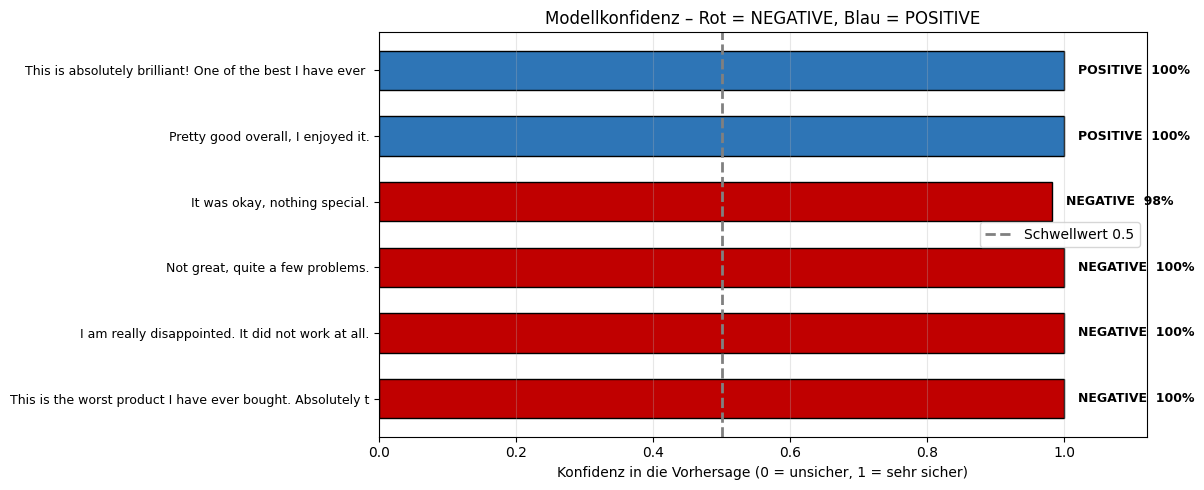


Lesehinweis:
  Balkenlänge = Konfidenz des Modells in seine Vorhersage
  Farbe       = vorhergesagte Klasse (Rot=NEGATIV, Blau=POSITIV)
  Alle Balken sind sichtbar – egal ob positiv oder negativ.


In [21]:
texte_graduell = [
    "This is the worst product I have ever bought. Absolutely terrible.",
    "I am really disappointed. It did not work at all.",
    "Not great, quite a few problems.",
    "It was okay, nothing special.",
    "Pretty good overall, I enjoyed it.",
    "This is absolutely brilliant! One of the best I have ever experienced."
]

konfidenzwerte = []
labels_liste   = []

for text in texte_graduell:
    res = sentiment(text)[0]
    # Konfidenz in die Vorhersage (immer 0-1, unabhaengig von der Klasse)
    konfidenzwerte.append(res['score'])
    labels_liste.append(res['label'])

fig, ax = plt.subplots(figsize=(12, 5))

colors = ['#C00000' if l == 'NEGATIVE' else '#2E75B6' for l in labels_liste]
ax.barh(range(len(texte_graduell)), konfidenzwerte,
        color=colors, edgecolor='black', height=0.6)

ax.set_yticks(range(len(texte_graduell)))
ax.set_yticklabels([f'{t[:58]}' for t in texte_graduell], fontsize=9)
ax.set_xlabel('Konfidenz in die Vorhersage (0 = unsicher, 1 = sehr sicher)')
ax.set_title('Modellkonfidenz – Rot = NEGATIVE, Blau = POSITIVE')
ax.axvline(0.5, color='gray', linestyle='--', linewidth=2, label='Schwellwert 0.5')
ax.set_xlim(0, 1.12)
ax.legend()
ax.grid(True, alpha=0.3, axis='x')

for i, (v, l) in enumerate(zip(konfidenzwerte, labels_liste)):
    ax.text(v + 0.02, i, f'{l}  {v:.0%}', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

print()
print("Lesehinweis:")
print("  Balkenlänge = Konfidenz des Modells in seine Vorhersage")
print("  Farbe       = vorhergesagte Klasse (Rot=NEGATIV, Blau=POSITIV)")
print("  Alle Balken sind sichtbar – egal ob positiv oder negativ.")


# Schritt 18: Beobachtungsaufgabe 3 – Konfidenz

## Aufgaben

**Aufgabe A – Eigene Textreihe:**
Erstellen Sie eine eigene Reihe von 4–6 Texten, die graduell von eindeutig negativ
zu eindeutig positiv übergehen, und visualisieren Sie die Konfidenzwerte.

**Aufgabe B – Schwellwert-Experiment:**
Was passiert, wenn Sie den Schwellwert von 0.5 auf 0.8 erhöhen?
- Wie viele Texte würden dann als „unsicher" (unter dem Schwellwert) klassifiziert?
- In welchen Anwendungen wäre ein höherer Schwellwert sinnvoll?

In [17]:
# Ihr Experiment: eigene Textreihe
meine_texte = [
    "This is absolutely terrible.",    # eindeutig negativ
    "Not great.",
    "It was fine.",
    "Pretty good actually.",
    "This is absolutely wonderful!"   # eindeutig positiv
]

# TODO: Klassifizieren und visualisieren Sie meine_texte
# Orientieren Sie sich an Schritt 17

results = []
for t in meine_texte:
    r = sentiment(t)[0]
    score = r['score'] if r['label'] == 'POSITIVE' else 1 - r['score']
    results.append((t, score, r['label']))
    print(f"  {t:<45} → {r['label']}  {score:.1%}")

  This is absolutely terrible.                  → NEGATIVE  0.0%
  Not great.                                    → NEGATIVE  0.0%
  It was fine.                                  → POSITIVE  100.0%
  Pretty good actually.                         → POSITIVE  100.0%
  This is absolutely wonderful!                 → POSITIVE  100.0%


# Schritt 19: Zusammenfassung
## Was haben wir gelernt?

| Konzept | Kernaussage |
|---------|-------------|
| **Transformer / Self-Attention** | Verarbeitet alle Wörter parallel – nicht sequenziell |
| **BERT / DistilBERT** | Vortrainiertes Sprachmodell – analoges zu VGG19 für Text |
| **Tokenisierung** | Text → Token-IDs → Eingabe für das Modell |
| **Parameter: „Large"** | DistilBERT 66 Mio., BERT 110 Mio., GPT-3 175 Mrd. |
| **Sentiment-Analyse** | Fine-Tuned BERT für Pos/Neg-Klassifikation |
| **Zero-Shot** | Kategorien frei wählen via NLI – kein Training nötig |
| **Konfidenz** | Wahrscheinlichkeit + Schwellwert – wie in Kap. 5 |
| **Grenzen** | Sarkasmus, Ironie, komplexe Verneinungen sind schwierig |

### Wissenstest
1. Warum braucht Zero-Shot-Klassifikation keine Trainingsdaten?
2. Was ist der Unterschied zwischen Pre-Training und Fine-Tuning bei BERT?
3. Nennen Sie zwei Praxisanwendungen, wo Zero-Shot besonders vorteilhaft wäre.
4. Was sind die Grenzen der hier verwendeten Modelle?

### Weiterführend (optional)
- Deutsches Modell: `'oliverguhr/german-sentiment-bert'`
- Andere Pipelines: `'summarization'`, `'translation_en_to_de'`, `'ner'`
- Hugging Face Model Hub: https://huggingface.co/models

# Schritt 20: Merksatz

## Merksatz

**Large Language Models wie BERT und GPT sind der Transfer-Learning-Ansatz für Sprache:
vortrainiert auf riesigen Textmengen, fine-tuned für spezifische Aufgaben –
mit dramatisch weniger Daten und Rechenaufwand als ein Training von Grund auf.**

Kernpunkte:

- `pipeline()` kapselt Tokenisierung + Modell + Dekodierung – wie scikit-learns Pipeline
- Zero-Shot funktioniert, weil das Modell durch NLI-Training gelernt hat, ob ein Text zu einer Beschreibung passt
- „Large" bedeutet konkret: 66 Mio. bis 175 Mrd. Parameter – unser CNN hatte 225.000
- Grenzen: Sarkasmus, Ironie, Domänen-Shift, mehrsprachige Texte

> **Nächstes Notebook:** Feinabstimmung (Fine-Tuning) von BERT auf eigenen Daten